In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

In [48]:
movies = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')

In [49]:
df = ratings.merge(movies, on='movieId')

In [50]:
df = df[df['genres'] != '(no genres listed)']

In [51]:
df['reward'] = df['rating'].apply(lambda rating: 1 if rating >= 4 else 0)

In [52]:
df['genre_list'] = df['genres'].apply(lambda x: x.split('|'))

In [53]:
df.head()

,userId,movieId,rating,timestamp,title,genres,reward,genre_list
0,1,16,4.0,1217897793,Casino (1995),Crime|Drama,1,"[Crime, Drama]"
1,1,24,1.5,1217895807,Powder (1995),Drama|Sci-Fi,0,"[Drama, Sci-Fi]"
2,1,32,4.0,1217896246,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,1,"[Mystery, Sci-Fi, Thriller]"
3,1,47,4.0,1217896556,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,1,"[Mystery, Thriller]"
4,1,50,4.0,1217896523,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,1,"[Crime, Mystery, Thriller]"


In [54]:
all_genres = set()

for genres in df['genre_list']:
    for genre in genres:
        all_genres.add(genre)

genres = sorted(list(all_genres))
d = len(genres)

print(genres)
print(d)

['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
19


In [55]:
df['reward'].value_counts()

,count
reward,
0,53411
1,51921


In [56]:
movie_stats = df.groupby(['movieId', 'title', 'genres']).agg(
    avg_rating=('rating', 'mean'),
    rating_count=('rating', 'count')
).reset_index()

movie_stats = movie_stats[movie_stats['rating_count'] >= 10]

movie_stats.head()

,movieId,title,genres,avg_rating,rating_count
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.907328,232
1,2,Jumanji (1995),Adventure|Children|Fantasy,3.353261,92
2,3,Grumpier Old Men (1995),Comedy|Romance,3.189655,58
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,2.818182,11
4,5,Father of the Bride Part II (1995),Comedy,3.250000,62


In [57]:
genres_selected = []
rewards = []

genre_success = {genre: 0 for genre in genres}
genre_failure = {genre: 0 for genre in genres}

for row in df.itertuples():

    samples = {}

    for genre in genres:
        samples[genre] = random.betavariate(
            genre_success[genre] + 1,
            genre_failure[genre] + 1
        )

    selected_genre = max(samples, key=samples.get)

    if selected_genre in row.genre_list:
        reward = row.reward
    else:
        reward = 0

    if reward == 1:
        genre_success[selected_genre] += 1
    else:
        genre_failure[selected_genre] += 1

    genres_selected.append(selected_genre)
    rewards.append(reward)

In [58]:
total_reward = sum(rewards)

print("Total Reward:", total_reward)

Total Reward: 25381


In [59]:
genre_results = pd.DataFrame({
    'genre': genres,
    'success': [genre_success[g] for g in genres],
    'failure': [genre_failure[g] for g in genres]
})

genre_results['total'] = genre_results['success'] + genre_results['failure']
genre_results['success_rate'] = genre_results['success'] / genre_results['total']

genre_results.sort_values(by='success_rate', ascending=False)

,genre,success,failure,total,success_rate
7,Drama,25126,78170,103296,0.243243
4,Comedy,153,642,795,0.192453
5,Crime,29,172,201,0.144279
16,Thriller,23,155,178,0.129213
0,Action,14,109,123,0.113821
14,Romance,10,85,95,0.105263
1,Adventure,7,74,81,0.086420
13,Mystery,4,54,58,0.068966
15,Sci-Fi,4,61,65,0.061538
8,Fantasy,4,63,67,0.059701


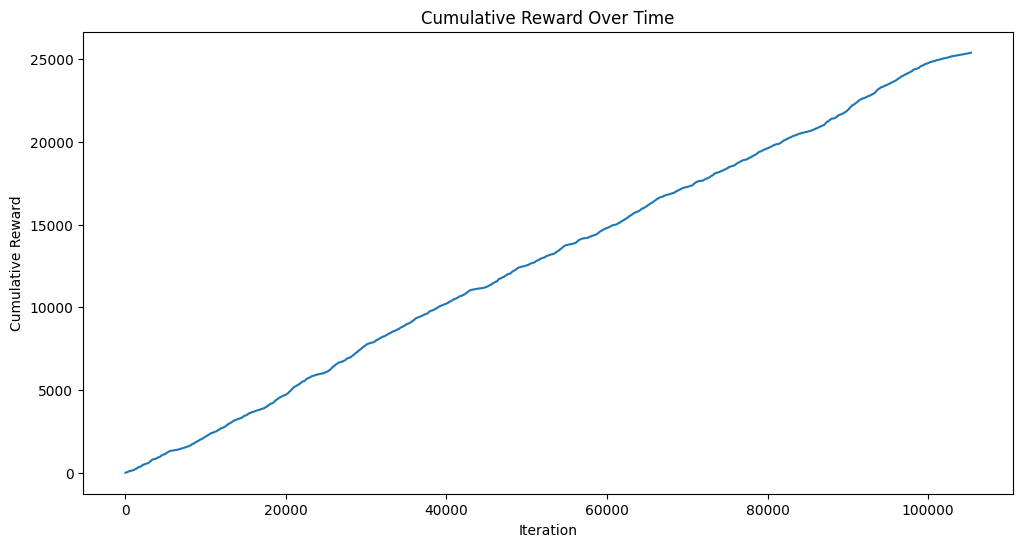

In [61]:
cumulative_rewards = np.cumsum(rewards)

plt.figure(figsize=(12, 6))
plt.plot(cumulative_rewards)
plt.title('Cumulative Reward Over Time')
plt.xlabel('Iteration')
plt.ylabel('Cumulative Reward')
plt.show()

In [62]:
best_genre = genre_results.sort_values(
    by='success_rate',
    ascending=False
).iloc[0]['genre']

print("Best Genre:", best_genre)

Best Genre: Drama


In [63]:
recommended_movies = movie_stats[
    movie_stats['genres'].apply(lambda x: best_genre in x.split('|'))
]

recommended_movies = recommended_movies.sort_values(
    by=['avg_rating', 'rating_count'],
    ascending=False
)

recommended_movies.head(10)

,movieId,title,genres,avg_rating,rating_count
943,1178,Paths of Glory (1957),Drama|War,4.500000,19
1496,1927,All Quiet on the Western Front (1930),Action|Drama|War,4.500000,13
1372,1730,Kundun (1997),Drama,4.500000,10
5172,7099,Nausicaä of the Valley of the Wind (Kaze no ta...,Adventure|Animation|Drama|Fantasy|Sci-Fi,4.477273,22
938,1172,Cinema Paradiso (Nuovo cinema Paradiso) (1989),Drama,4.459459,37
279,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.454545,308
8042,66934,Dr. Horrible's Sing-Along Blog (2008),Comedy|Drama|Musical|Sci-Fi,4.434783,23
1515,1949,"Man for All Seasons, A (1966)",Drama,4.409091,11
978,1217,Ran (1985),Drama|War,4.403226,31
185,213,Burnt by the Sun (Utomlyonnye solntsem) (1994),Drama,4.400000,10


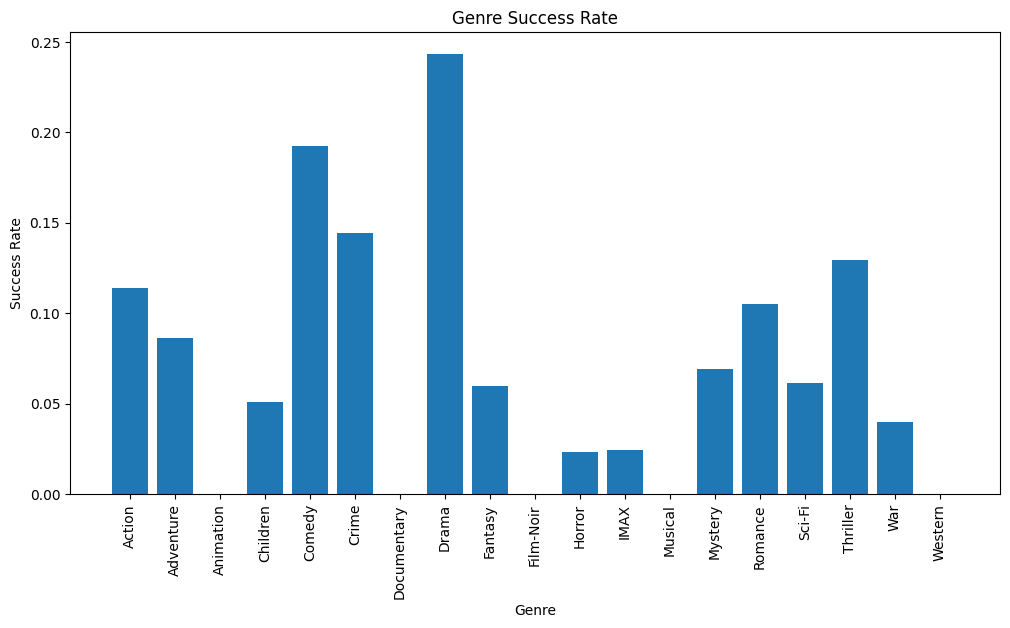

In [64]:
plt.figure(figsize=(12, 6))
plt.bar(genre_results['genre'], genre_results['success_rate'])
plt.xticks(rotation=90)
plt.title('Genre Success Rate')
plt.xlabel('Genre')
plt.ylabel('Success Rate')
plt.show()

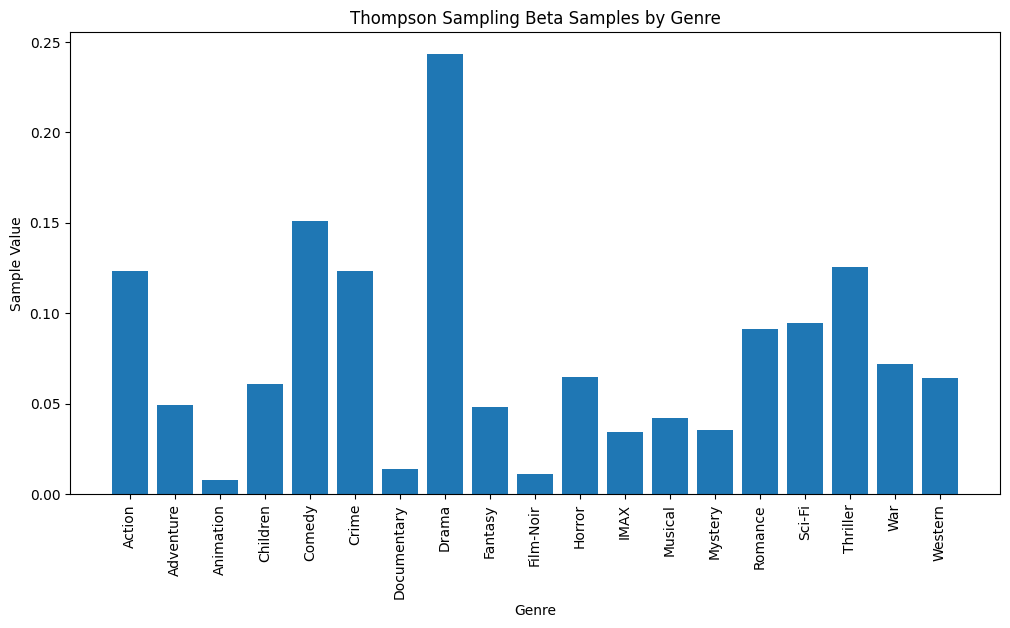

In [65]:
plt.figure(figsize=(12, 6))
plt.bar(samples.keys(), samples.values())
plt.xticks(rotation=90)
plt.title('Thompson Sampling Beta Samples by Genre')
plt.xlabel('Genre')
plt.ylabel('Sample Value')
plt.show()

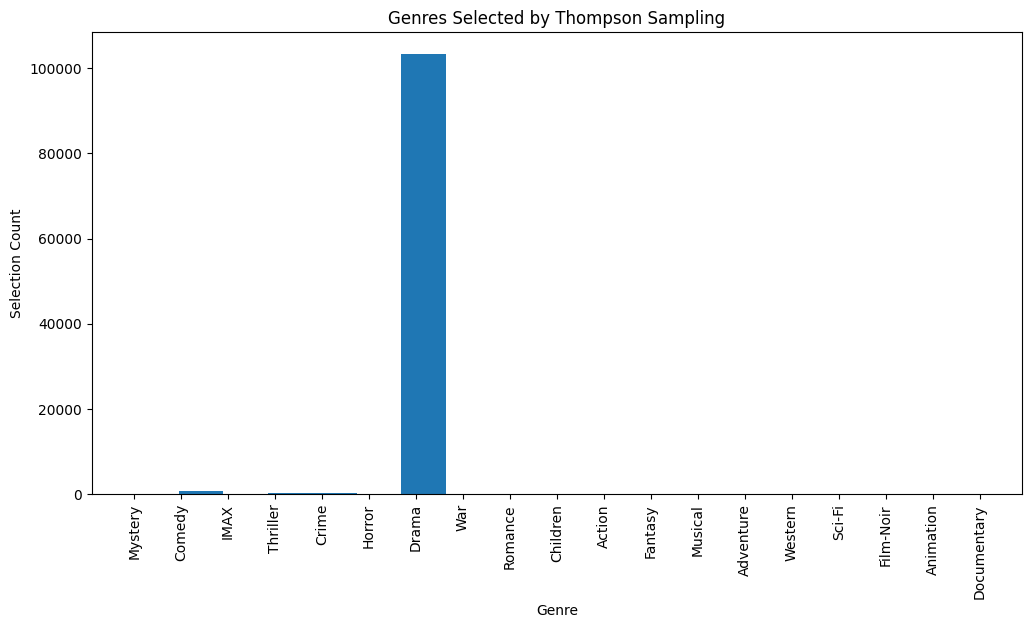

In [66]:
plt.figure(figsize=(12,6))

plt.hist(genres_selected, bins=len(genres))

plt.xticks(rotation=90)

plt.title("Genres Selected by Thompson Sampling")
plt.xlabel("Genre")
plt.ylabel("Selection Count")

plt.show()

In [67]:
best_genre = max(
    genre_success,
    key=lambda g: genre_success[g] / (genre_success[g] + genre_failure[g])
)

print(best_genre)

Drama


In [68]:
recommended_movies = movie_stats[
    movie_stats['genres'].apply(
        lambda x: best_genre in x.split('|')
    )
]

recommended_movies = recommended_movies.sort_values(
    by=['avg_rating', 'rating_count'],
    ascending=False
)

recommended_movies.head(10)

,movieId,title,genres,avg_rating,rating_count
943,1178,Paths of Glory (1957),Drama|War,4.500000,19
1496,1927,All Quiet on the Western Front (1930),Action|Drama|War,4.500000,13
1372,1730,Kundun (1997),Drama,4.500000,10
5172,7099,Nausicaä of the Valley of the Wind (Kaze no ta...,Adventure|Animation|Drama|Fantasy|Sci-Fi,4.477273,22
938,1172,Cinema Paradiso (Nuovo cinema Paradiso) (1989),Drama,4.459459,37
279,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.454545,308
8042,66934,Dr. Horrible's Sing-Along Blog (2008),Comedy|Drama|Musical|Sci-Fi,4.434783,23
1515,1949,"Man for All Seasons, A (1966)",Drama,4.409091,11
978,1217,Ran (1985),Drama|War,4.403226,31
185,213,Burnt by the Sun (Utomlyonnye solntsem) (1994),Drama,4.400000,10
